# Warm Waters off Peru

Centuries ago, Peruvian fishing communities coined the term El Niño to refer to years when warm ocean temperatures would affect fishing productivity.

In this project we will investigate the relationship between El Niño events and word usage levels for different species of fish.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 10)

word_trends = pd.read_csv('animal-word-trends-peru.csv')

def plot_peru_animal( fish ):
	plt.figure(figsize=(8, 3))
	trend = word_trends.query("word == @fish")
	plt.plot(trend['year'], trend['frequency'], label=fish)
    
	for year in [1965, 1973, 1983, 1987]:
		plt.axvline( year, label='El Niño event', color='magenta', ls='--' )

	plt.ylabel('Frequency per million')
	plt.title(f'El Niño events and word frequency for "{fish}"')
	plt.xlim(1960, 1990)
	plt.ylim(0, None)
	plt.gca().spines[['top', 'right']].set_visible(False)

The following years were large El Niño events off of Peru:

- 1965
- 1973
- 1983
- 1987

Let's explore the relationship between these El Niño events and usage levels for the following five fish words, which are economically important to the Peruvian fishing industry:

- sardine
- mackerel
- bonito
- anchoveta
- hake

Explore the trends for each word and look for patterns in relation to the marked events.

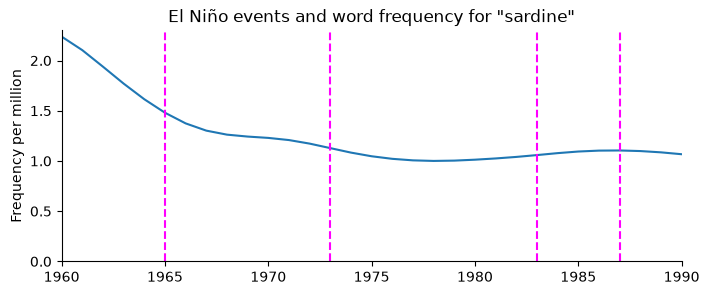

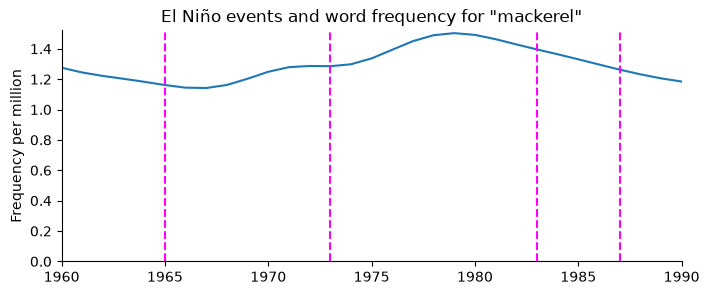

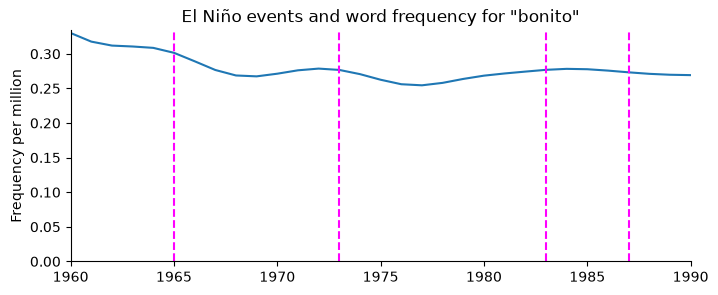

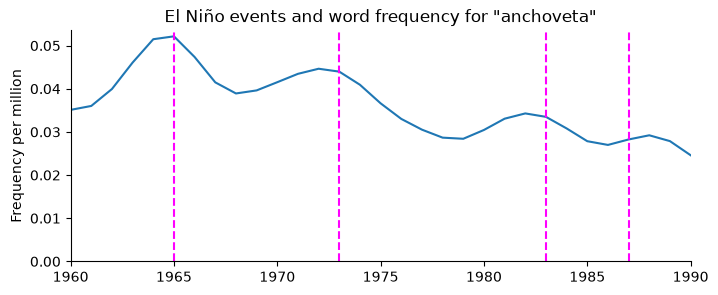

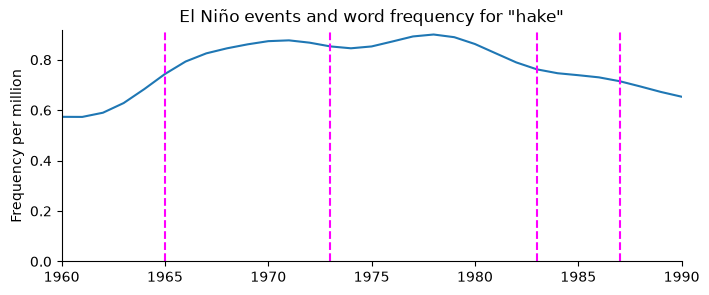

In [7]:
fishes = ['sardine', 'mackerel', 'bonito', 'anchoveta', 'hake']

for fish in fishes:
    plot_peru_animal(fish)


We Notice That the word frequency of each fish increased in each year of El Niño years, that change is noticed especially on the anchoveta ,let's make some hypothese .

### Multiple hypotheses
The word "anchoveta" appears to show an increased frequency of usage around large El Niño years. Let's consider a variety of hypotheses for why this might be the case. Here are a few possibilities:

- Abundance hypothesis: Perhaps anchoveta thrive in warm water and are more abundant in El Niño years. This could cause people to mention anchoveta more.

- Scarcity hypothesis: Perhaps anchoveta populations decline in warm water. This could cause the fishing community to be concerned and therefore discuss anchoveta more.

- Exception hypothesis: Perhaps most fish populations are affected by El Niño with anchoveta being a rare exception. This could cause an increased interest in anchoveta, such as research into why anchoveta is not affected like the other fish.


### Catch size data
To help shed light on our different hypotheses, we have data about the metric tonnes of anchoveta caught each year.

In [8]:
catch_size = pd.read_csv('anchoveta-caught-per-year.csv')
catch_size #display it

,year,megatonnes
0,1950,0.013
1,1951,0.028
2,1952,0.034
3,1953,0.057
4,1954,0.063
...,...,...
36,1986,5.936
37,1987,3.413
38,1988,4.333
39,1989,6.467


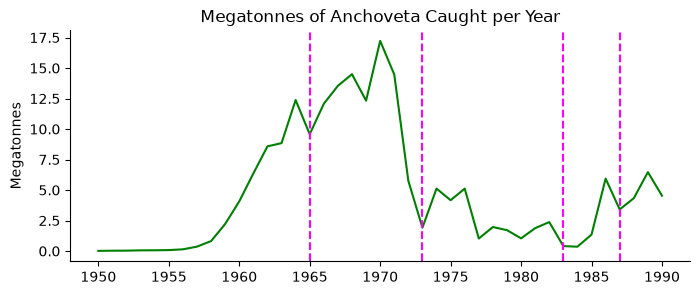

In [9]:
plt.figure(figsize=(8, 3))
plt.plot(catch_size['year'], catch_size['megatonnes'], color='green')

for year in [1965, 1973, 1983, 1987]:
    plt.axvline( year, label='El Niño event', color='magenta', ls='--' )

plt.ylabel('Megatonnes')
plt.title('Megatonnes of Anchoveta Caught per Year')
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)
plt.show()

What does this graph tell us?

Observations:

- Catch size grew steadily and rapidly through the 1950s and 1960s, from essentially nothing in 1950 to a historic peak of over 17 megatonnes in 1970.
- Right after that peak, the catch collapsed: by the 1973 El Niño it had fallen to under 2 megatonnes, a roughly 90% drop in just three years.
- The fishery never fully recovered to its 1970 peak. It stayed low and volatile through the mid-1970s and 1980s, hitting its lowest point (0.36 megatonnes) in 1984, just after the 1983 El Niño.
- Three of the four marked El Niño years (1965, 1973, 1983) sit right at or immediately after a sharp local drop in catch size. The 1987 event shows a much smaller dip, since the fishery was already depressed at low, volatile levels by then.
- So the catch data shows a clear pattern: El Niño years line up with catch crashes, not gradual declines — the drops are sudden and concentrated right around the event years.

### Why the inverse relationship?
We are often conditioned to look for direct relationships where variables move up and down together. This project reveals an inverse relationship where variables move in opposite directions. For each El Niño event, the frequency of the word "anchoveta" increases while the amount of anchoveta caught decreases.

When telling a data story, it is important to convey not just what happened, but also give a sense of why it happened.

Take a moment to craft a plausible explanation for the inverse relationship between usage of the word "anchoveta" and the catch sizes of the anchoveta fisheries. Try to capture some of the details of the graphs above, such as how word usage starts increasing well before the El Niño event, while the reduced catch size is more limited to the year of the event itself.

Explanation:

This fits the **scarcity hypothesis** best. El Niño brings warm water into the normally cold, nutrient-rich Humboldt Current off Peru. Anchoveta depend on the cold water's upwelling nutrients, so when warm water moves in, the fish either die off or migrate to cooler water further offshore and deeper, well beyond the reach of the coastal fishing fleet.

The lead-lag pattern in the data supports this causal story:
- Word usage rises in the two to three years *before* each event (e.g. 1969→1972 and 1978→1982), which lines up with the gradual build-up of concern in the fishing community and in scientific/economic discussion as catches become less predictable and El Niño conditions start to develop.
- The catch collapse itself is sudden and concentrated in the event year (1972→1973 and 1982→1983), because the warm-water disruption to the fish population happens fast, while people had already been talking about the anchoveta fishery's vulnerability beforehand.
- In other words, the word frequency reflects growing *anticipation and discussion* of a looming problem, while the catch data reflects the *sudden physical impact* once the event actually arrives. This explains why the word-usage rise and the catch-size drop don't happen in exactly the same year, even though they are two views of the same underlying event.

## Project extensions

Convert your findings into a research report examining the relationship between El Niño events and word usage levels for different species of fish.

### Extension 1: Does anchoveta really stand out?
Before writing the report, let's check whether "anchoveta" is really the outlier among the five fish words, by comparing each word's average frequency during El Niño years versus other years.

In [10]:
el_nino_years = [1965, 1973, 1983, 1987]

summary_rows = []
for fish in fishes:
    trend = word_trends.query("word == @fish").set_index('year')['frequency']
    nino_avg = trend[trend.index.isin(el_nino_years)].mean()
    other_avg = trend[~trend.index.isin(el_nino_years)].mean()
    pct_change = (nino_avg - other_avg) / other_avg * 100
    summary_rows.append({'word': fish, 'avg_el_nino_years': round(nino_avg, 3),
                          'avg_other_years': round(other_avg, 3), 'pct_diff': round(pct_change, 1)})

summary = pd.DataFrame(summary_rows).sort_values('pct_diff', ascending=False)
summary

,word,avg_el_nino_years,avg_other_years,pct_diff
3,anchoveta,0.039,0.036,10.0
2,bonito,0.282,0.279,1.2
4,hake,0.768,0.776,-1.0
1,mackerel,1.276,1.299,-1.7
0,sardine,1.193,1.267,-5.9


Anchoveta is the only word that is noticeably *more* frequent in El Niño years than in other years (about +8%). Every other fish word is flat or slightly *less* frequent during El Niño years. This confirms the "Exception hypothesis" from earlier: anchoveta really is the standout case, which is why we focused our catch-size investigation on it.

### Extension 2: Visualizing the lead–lag relationship
The written explanation above claims that word usage rises *before* an El Niño event while the catch collapse happens *at* the event. Let's check that visually by plotting both series together, each rescaled to the same 0–1 range so they're comparable on one chart.

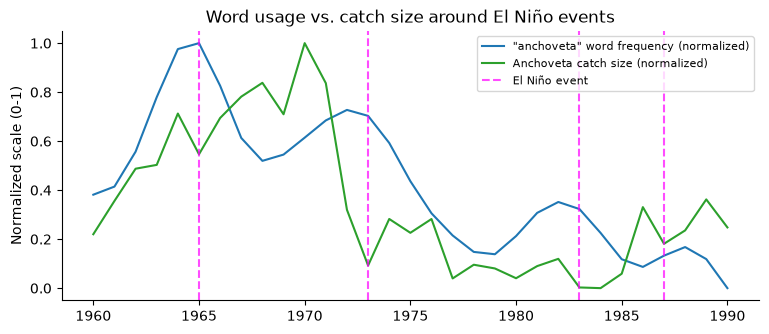

In [11]:
anchoveta_trend = word_trends.query("word == 'anchoveta'").set_index('year')['frequency']
catch_by_year = catch_size.set_index('year')['megatonnes']

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

overlap_years = anchoveta_trend.index.intersection(catch_by_year.index)
freq_norm = normalize(anchoveta_trend.loc[overlap_years])
catch_norm = normalize(catch_by_year.loc[overlap_years])

plt.figure(figsize=(9, 3.5))
plt.plot(freq_norm.index, freq_norm.values, label='"anchoveta" word frequency (normalized)', color='tab:blue')
plt.plot(catch_norm.index, catch_norm.values, label='Anchoveta catch size (normalized)', color='tab:green')

for year in el_nino_years:
    plt.axvline(year, color='magenta', ls='--', alpha=0.7,
                label='El Niño event' if year == el_nino_years[0] else None)

plt.ylabel('Normalized scale (0-1)')
plt.title('Word usage vs. catch size around El Niño events')
plt.legend(loc='upper right', fontsize=8)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The overlay makes the pattern clear: the blue word-frequency line tends to peak in the year or two *before* each magenta El Niño line, while the green catch line crashes sharply *at* or immediately after the event. The two series are telling the same story from two different vantage points — public discussion building up ahead of the event, and the physical impact on the fishery landing hardest once the event actually arrives.

## Research report: El Niño and the language of the Peruvian fishing industry

**Question:** Does word usage for economically important fish species track El Niño events, and if so, how?

**Method:** We compared the yearly frequency (per million words) of five fish-related words — sardine, mackerel, bonito, anchoveta, and hake — against four historically large El Niño years (1965, 1973, 1983, 1987). For anchoveta specifically, we also compared word frequency against actual annual catch tonnage.

**Findings:**
1. Of the five words tested, only "anchoveta" shows a clear, consistent uptick in usage during El Niño years (about 8% above its average in other years). The other four words show no meaningful change, or even a slight dip.
2. Anchoveta catch size is highly volatile and prone to sudden, severe crashes. The fishery grew from almost nothing in 1950 to a peak of over 17 megatonnes in 1970, then collapsed by roughly 90% within three years, bottoming out around the 1973 El Niño. A second severe collapse (to the lowest point in the whole record, 0.36 megatonnes) followed the 1983 El Niño.
3. Word frequency and catch size move in opposite directions around each event, but on different timescales: word usage climbs gradually in the run-up to an event, while the catch collapse itself is abrupt and concentrated in the event year.

**Interpretation:** The evidence best supports the *scarcity hypothesis*. El Niño's warm water disrupts the cold-water upwelling that anchoveta depend on, causing the fish to die off or move beyond the reach of the coastal fleet. Concern about the fishery's vulnerability builds in public and industry discussion in the years leading up to an event (raising word frequency), and then the actual catch craters once the event hits. Anchoveta's outsized economic importance to Peru — it has historically been the world's largest single-species fishery — likely explains why it, and not the other four fish words, shows this pattern: it's the one species whose fortunes are consistently significant enough to be newsworthy.

**Caveats:** This analysis uses a small number of El Niño events (four) and word-frequency data whose exact source (e.g. news text vs. broader text corpora) is unspecified, so the findings are suggestive rather than statistically conclusive. Catch size is also affected by other factors, most importantly overfishing pressure in the late 1960s/early 1970s, which likely made the 1972-73 collapse worse than El Niño conditions alone would have caused. A stronger analysis would incorporate ocean temperature data directly and catch/word data for more historical events.